# Koopman operator learning, a toy case: Duffing oscillator

## Instructions

- You must submit **two files**:
  1. **This notebook**, fully completed and including the output of the cells.  
     The notebook will **not** be executed during grading; it will be **read**.  
     Make sure it is clear, well presented, and easy to follow, since presentation will be taken into account in the grading.
  2. **A `.npy` file** containing some of the results of your experiments.  
     You can generate this file from the `results` dictionary using the relevant cells (see below + end of notebook).  
     This dictionary will be progressively completed with the relevant results during the practical session. Make sure it contains all the required results before generating the file.

- Make sure to **follow all naming conventions exactly** when submitting both files.

In [97]:
import numpy as np

results = {}
results["id"] = np.random.randint(0, 100000)

In [98]:
name = "KAPOTOS_DEGENEVE"  # TODO
file_path = f"results_{name}.npy"
np.save(file_path, results)

In [99]:
# Run this cell to check that your .npy file has been correctly saved and contains the expected results.
loaded_results = np.load(file_path, allow_pickle=True).item()
print(loaded_results.keys())

dict_keys(['id'])



The aim of this notebook is to describe the dynamics of a non-linear dynamical system by means of the Koopman theory.

## Introduction

We consider a quantity $x \in \mathbb{R}^n$ (a vector) which evolves with time, following a dynamical system. Think for example of the joint location of the planets in our solar system, which follows the law of gravitation.

Formally, given an initial state $x(t=0) \in \mathbb{R}^n$ at time $t=0$, the time evolution of $x$ is governed by the following dynamical system:
$$
\dot{x}(t) = f(x(t)) \quad \text(1)
$$

where $\dot{x}(t) := \frac{dx(t)}{dt}$ is the temporal derivative, and $f:\mathbb{R}^n \rightarrow \mathbb{R}^n$ is a given map describing the dynamics.

For a given $f$, it is not always possible to solve the differential equation (1) analytically. For this reason, instead, numerical schemes are usually employed, to integrate in time $t$ the equation (1), so as to propagate the initial condition $x(0)$ up to a desired time $T$; think of $x(T) = x(0) + \int_{t=0}^{T} f(x(t)) dt$. The discretization in time of eq (1) or of the integral introduces numerical approximations, and yields estimates of $x(T)$ of various quality depending on the discretization scheme.

In the field of numerical simulations, discretization schemes have been studied for a long time, and numerical solvers already exist to provide good estimates of integrals (far better than with the naive discretization $x_{k+\delta} = x_k + \delta\,f(x_k)$ for a discrete time increment $\delta$, which induces a $O(\delta^2)$ error at each time step).

The goal of this practical session is to make use of such numerical solvers to improve the learning of dynamical systems with neural networks.

In [100]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import sys
from tqdm import tqdm

from torch.utils.data import TensorDataset, DataLoader
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.autograd as autograd

# arrange the dataset
from sklearn.model_selection import train_test_split

## Duffing oscillator

As a toy example, we consider the Duffing oscillator, where the state $x = (x_1, x_2) \in \mathbb{R}^2$ follows the dynamical system described by the following ODEs:

$$
\dot{x}_1 = x_2\\
\dot{x}_2 = x_1 - x_1^3
$$

To integrate in time the ODEs, a 4th order Runge-Kutta scheme can be used. 


In [101]:
def duffing(array_x: np.ndarray) -> np.ndarray:
    array_dx = np.zeros(array_x.shape)
    array_dx[0] = array_x[1]
    array_dx[1] = array_x[0] - array_x[0] ** 3
    return array_dx

In [102]:
t_max = 500  # Time-horizon integration
n_iter = 5000  # Number of time steps integration
n_initial_conditions = 60  # Number of initial conditions

dim_system = 2

# Generate initial conditions
matrix_x0 = (np.random.rand(n_initial_conditions, dim_system) - 0.5) * 4  # Uniform distribution in [-2, 2]
array_t = np.linspace(0, t_max, n_iter)
array3d_xt = np.zeros((matrix_x0.shape[0], matrix_x0.shape[1], n_iter))

for i in tqdm(range(matrix_x0.shape[0])):
    # Lambda function is used as solve_ivp requires a function of the form f(t, x)
    ode_result = solve_ivp(
        lambda _t, array_x: duffing(array_x), [0, t_max], matrix_x0[i], method="RK45", t_eval=array_t
    )

    array3d_xt[i, :] = ode_result.y

  3%|▎         | 2/60 [00:00<00:07,  8.13it/s]

100%|██████████| 60/60 [00:06<00:00,  9.09it/s]


The following plot shows trajectories for different initial conditions:

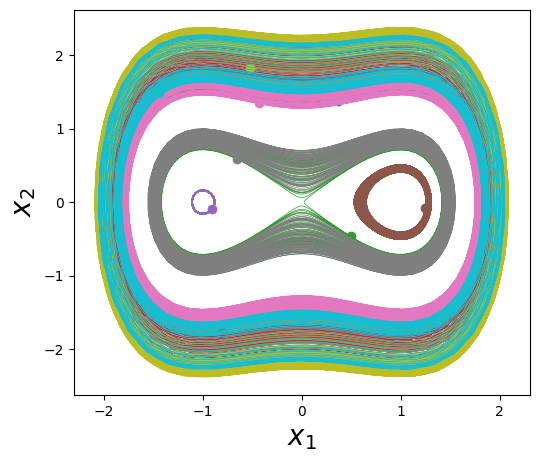

In [103]:
fig = plt.figure(figsize=(20, 5))
ax = fig.add_subplot(131)
cm = plt.get_cmap("tab10")
print(cm)
for i in range(10):
    ax.plot(array3d_xt[i, 0, :], array3d_xt[i, 1, :], lw=0.5, color=cm(i))
    ax.plot(array3d_xt[i, 0, 0], array3d_xt[i, 1, 0], "o", lw=1.5, color=cm(i))  # initial condition
ax.set_xlabel("$x_1$", fontsize=20)
ax.set_ylabel("$x_2$", fontsize=20)
plt.show()

## The Koopman operator
### Discontinuous in time case
Given the discrete non-linear dynamical system

$$
x_{k+1} = F(x_k)
$$

where $F$ might be the $\delta$-discretised flow map of the continuous dynamical system in eq (1) given by

$$
x_{k+1} = F(x_k) := x_k + \int_{k}^{k + \delta} f(x(s))ds 
$$

and $X = (x_k)_{k = 0}^N$ the discrete time series of the system state.


The _Koopman_ theory states that there exists an infinite-dimensional linear operator $\mathcal{K}$ that advances in time all observable functions $(g_i)_{i = 1}^m$ given by $g_i: \mathbb{R}^n \rightarrow \mathbb{R}$

$$
\mathcal{K} g_i(x) = g_i \circ F(x)
$$

This way, the non-linear dynamics of $x$, described by $F$, can be turned into a **linear** dynamical system, described by $\mathcal{K}$, acting on another representation space, formed by the observable quantities $g_i(x)$.

Indeed, let $g_i$ be an observable function and denoting ${g_i}_k := g_i(x_k)$, using the previous equation, the time evolution of the observables is given by

$$
{g_i}_{k+1} = g_i(x_{k+1}) = g_i(F(x_k)) = g_i \circ F(x_k) = \mathcal{K} g_i(x_k) = \mathcal{K} {g_i}_k
$$

then, the linearised dynamics of the observables is given by the following equation

$$
{g_i}_{k+1} = \mathcal{K} {g_i}_k
$$


It is then sufficient to find a function $g: \mathbb{R}^n \rightarrow \mathbb{R}^m$ with $m \gg n$ that embeds the state $x$ into a "larger enough" dimensional space $m$ such that the linear operator $\mathcal{K}$ can be inferred by a matrix $\mathbf{K} \in \mathbb{R}^{m \times m}$.

To project back the dynamics from the Koopman space ($\mathbb{R}^m$, where $g(x)$ lives) to the phase space ($\mathbb{R}^n$, where $x$ lives), a supplementary function $\varphi: \mathbb{R}^m \rightarrow \mathbb{R}^n$ is needed. Going from $x$ to the Koopman space and back yields $\varphi \text{ o  } g = $ Id.

Under this condition, the functions $g$, $\varphi$ and $\mathbf{K}$ can be parametrized $g_{\theta}$, $\varphi_{\rho}$ and $\mathbf{K}_{\phi}$, and the parameters $\theta$, $\rho$ and $\phi$ can be learned minimizing suitable loss functions. 

For this purpose, given a time series $X = \{x_k | k = 1 \ldots N \}$, the following conditions hold:


1.   Reconstruction error
     $$
     \Vert \varphi_\rho (g_\theta(x_k)) - x_k  \Vert = 0
     $$
2.   Prediction error in Koopman space
     $$
     \Vert \mathbf{K_{\phi}} g_{\theta} ( x_k ) - g_{\theta} (x_{k+1})  \Vert = 0
     $$
3.   Prediction error in the phase space
     $$
     \Vert \varphi_{\rho} \left( \mathbf{K_{\phi}} g_{\theta} ( x_k )\right) - x_{k+1} \Vert = 0
     $$

The last three errors can be used as loss functions to train three different neural networks. These different neural networks compose our architecture that can be summarized as in the following sketch:



![architecture](./architecture.png) 

In [104]:
# Flatten the trajectories w.r.t. initial conditions
# and only keep data in the form of (dim_system, n_iter * n_initial_conditions)
matrix_x_data = array3d_xt[:, :, :-1].swapaxes(0, 1).reshape(2, -1).T
matrix_x_next_data = array3d_xt[:, :, 1:].swapaxes(0, 1).reshape(2, -1).T

(matrix_x_data_train, matrix_x_data_test, matrix_x_next_data_train, matrix_x_next_data_test) = (
    train_test_split(matrix_x_data, matrix_x_next_data, test_size=0.2, random_state=0)
)

# Cast type to float32 and normalise the phase space.
# The three losses are then on a more comparable scale.
matrix_x_data_train = matrix_x_data_train.astype(np.float32)
matrix_x_data_test = matrix_x_data_test.astype(np.float32)
matrix_x_next_data_train = matrix_x_next_data_train.astype(np.float32)
matrix_x_next_data_test = matrix_x_next_data_test.astype(np.float32)

phase_mean = matrix_x_data_train.mean(axis=0, keepdims=True)
phase_std = matrix_x_data_train.std(axis=0, keepdims=True) + 1e-6

matrix_x_data_train = (matrix_x_data_train - phase_mean) / phase_std
matrix_x_data_test = (matrix_x_data_test - phase_mean) / phase_std
matrix_x_next_data_train = (matrix_x_next_data_train - phase_mean) / phase_std
matrix_x_next_data_test = (matrix_x_next_data_test - phase_mean) / phase_std

print(
    matrix_x_data_train.shape,
    matrix_x_data_test.shape,
    matrix_x_next_data_train.shape,
    matrix_x_next_data_test.shape,
)


(239952, 2) (59988, 2) (239952, 2) (59988, 2)


In [105]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [106]:
torch.set_default_dtype(torch.float32)
# torch.set_default_tensor_type('torch.DoubleTensor')

batch_size = 2000  # data per batch

tensor2d_x_data_train = torch.from_numpy(matrix_x_data_train).to(device)
tensor2d_x_next_data_train = torch.from_numpy(matrix_x_next_data_train).to(device)
tensor2d_x_data_test = torch.from_numpy(matrix_x_data_test).to(device)
tensor2d_x_next_data_test = torch.from_numpy(matrix_x_next_data_test).to(device)

torch_dataset_train = TensorDataset(tensor2d_x_data_train, tensor2d_x_next_data_train)

torch_dataset_test = TensorDataset(tensor2d_x_data_test, tensor2d_x_next_data_test)

train_dataloader = DataLoader(torch_dataset_train, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(torch_dataset_test, batch_size=batch_size, shuffle=True)

# create the models
feature_dim = 2  # dimension of the Duffing oscillator
hidden_layer = 5  # number of hidden layers in g (ENCODER) and \varphi (DECODER)
output_dim = 30  # dimension in Koopman space

In [107]:
class Encoder(nn.Module):
    def __init__(self, list_layer_dim: list):
        super().__init__()
        self.list_layer_dim = list_layer_dim
        self.list_FC = nn.ModuleList()
        for i in range(len(self.list_layer_dim) - 1):
            input_dim = self.list_layer_dim[i]
            output_dim = self.list_layer_dim[i + 1]
            self.list_FC.append(nn.Linear(input_dim, output_dim))

    def forward(self, tensor2d_x):
        for i in range(len(self.list_layer_dim) - 2):
            tensor2d_x = F.elu(self.list_FC[i](tensor2d_x))
        return self.list_FC[-1](tensor2d_x)


In [108]:
class Decoder(nn.Module):
    def __init__(self, list_layer_dim: list):
        super().__init__()
        self.list_layer_dim = list_layer_dim
        self.list_FC = nn.ModuleList()
        for i in range(len(self.list_layer_dim) - 1, 0, -1):
            input_dim = self.list_layer_dim[i]
            output_dim = self.list_layer_dim[i - 1]
            self.list_FC.append(nn.Linear(input_dim, output_dim))

    def forward(self, tensor2d_x: torch.Tensor):
        for i in range(len(self.list_layer_dim) - 2):
            tensor2d_x = F.elu(self.list_FC[i](tensor2d_x))
        return self.list_FC[-1](tensor2d_x)

In [109]:
class Autoencoder(nn.Module):
    def __init__(self, feature_dim: int, hidden_layer: int, output_dim: int):
        super().__init__()
        list_layer_dim = [
            output_dim if i == hidden_layer else feature_dim + i * (output_dim - feature_dim) // hidden_layer
            for i in range(hidden_layer + 1)
        ]
        self.encoder = Encoder(list_layer_dim)
        self.decoder = Decoder(list_layer_dim)

    def forward(self, tensor2d_x: torch.Tensor):
        tensor2d_x = self.Encoder(tensor2d_x)
        return self.Decoder(tensor2d_x)

The Koopman operator $\mathbf{K}$ (which is linear, and thus a matrix) must have a [spectral radius](https://en.wikipedia.org/wiki/Spectral_radius) $\rho(\mathbf{K})\le 1$. Such condition will provide a stable -or at least a marginally stable- Koopman operator. To fulfill this requirement, we might leverage on the Perron-Frobenius theorem. 

The Perron-Frobenius th. states: if $\mathbf{K}$ is a $m \times m$ positive matrix i.e. $k_{ij} > 0$ for $1 \le i,j \le m$, then the following inequality holds:

$$
\min_i \sum_j k_{ij} \le \rho(\mathbf{K}) \le \max_i \sum_j k_{ij}
$$


**Question 1.** : Complete the `KoopmanModule` class to enforce $\rho(\mathbf{K})\le 1$, using the Perron-Frobenius theorem. Check that the initialization fulfills this property.

In [110]:
class KoopmanOperator(nn.Module):
    def __init__(self, koopman_operator_dim: int):
        super().__init__()
        self.koopman_operator_dim = koopman_operator_dim
        self.raw_weight = nn.Parameter(torch.randn(koopman_operator_dim, koopman_operator_dim) * 0.02)

    def koopman_matrix(self) -> torch.Tensor:
        # Each row is positive and sums to 1, so the spectral radius is <= 1.
        return F.softmax(self.raw_weight, dim=1)

    def forward(self, tensor2d_x: torch.Tensor):
        if tensor2d_x.shape[1] != self.koopman_operator_dim:
            sys.exit(
                f"Wrong Input Features. Please use tensor with {self.koopman_operator_dim} Input Features"
            )
        return tensor2d_x @ self.koopman_matrix().T


dim_observable = 10
koopman_operator = KoopmanOperator(dim_observable).to(device)
results["koopman_operator_weight"] = koopman_operator.koopman_matrix().cpu().detach().numpy()
results["koopman_operator_forward"] = (
    koopman_operator(torch.ones(1, dim_observable).to(device)).cpu().detach().numpy()
)


In [111]:
# TODO: Check the spectrum initialisation
K = KoopmanOperator(10).koopman_matrix()
eigenvalues = torch.linalg.eigvals(K)
spectral_radius = torch.max(torch.abs(eigenvalues))
print(f"Spectral radius at initialisation: {spectral_radius:.6f}")


Spectral radius at initialisation: 1.000000


In [112]:
autoencoder = Autoencoder(feature_dim, hidden_layer, output_dim).to(device)
koopman_operator = KoopmanOperator(output_dim).to(device)
print(autoencoder)

Autoencoder(
  (encoder): Encoder(
    (list_FC): ModuleList(
      (0): Linear(in_features=2, out_features=7, bias=True)
      (1): Linear(in_features=7, out_features=13, bias=True)
      (2): Linear(in_features=13, out_features=18, bias=True)
      (3): Linear(in_features=18, out_features=24, bias=True)
      (4): Linear(in_features=24, out_features=30, bias=True)
    )
  )
  (decoder): Decoder(
    (list_FC): ModuleList(
      (0): Linear(in_features=30, out_features=24, bias=True)
      (1): Linear(in_features=24, out_features=18, bias=True)
      (2): Linear(in_features=18, out_features=13, bias=True)
      (3): Linear(in_features=13, out_features=7, bias=True)
      (4): Linear(in_features=7, out_features=2, bias=True)
    )
  )
)


In [113]:
torch.manual_seed(0)
np.random.seed(0)

learning_rate_autoencoder = 3e-4
learning_rate_koopman = 1e-4

optimiser_autoencoder = torch.optim.Adam(
    autoencoder.parameters(), lr=learning_rate_autoencoder, weight_decay=1e-6
)
optimiser_koopman = torch.optim.Adam(koopman_operator.parameters(), lr=learning_rate_koopman)


**Question 2.** : Define a function to compute the loss to be minimized. It should at least include the 3 terms listed above:
- Reconstruction error
- Prediction error in the Koopman space
- Prediction error in the phase space

Because the different objectives outlined by these losses may compete, the training can be difficult. You may try different variations on these losses and comment your findings. In order to improve the training process, one can for instance:
- Add a multiplicative factor in front of each loss component, to balance their importance; how the scales of different losses are related?
- We can refine the loss acting upon the latent space, by using a variational autoencoder approach. This is similar to the Gaussian likelihood used in the first practical (TD1). We want the prediction in the latent space (i.e. the Koopman space) to be a normal distribution $\mathcal{N}(0, 1)$ . Add a corresponding loss for the latent space. Difference to 0 mean and 1 standard deviation must be thus included in the loss;
- Freeze the gradients of one part of the network, for instance the encoder, for one specific objective, using the [`requires_grad`](https://pytorch.org/docs/stable/generated/torch.Tensor.requires_grad_.html) property. For instance:
```python
criterion = nn.MSELoss()
...
# Compute one part loss_l of the total loss
# First deactivate gradient computation for irrelevant parts of the architecture
for p in autoencoder.encoder.parameters():
    p.requires_grad = False
loss_l = criterion(pred, target)
# Restore the gradient computation
for p in autoencoder.encoder.parameters():
    p.requires_grad = True
...
total_loss = loss_1 + ... + loss_l + ...
```

In [114]:
def loss_koopman(
    tensor2d_x: torch.Tensor,
    tensor2d_x_next: torch.Tensor,
    tensor2d_observable: torch.Tensor,
    tensor2d_decoded_x: torch.Tensor,
    tensor2d_observable_next: torch.Tensor,
    tensor2d_koopman_observable: torch.Tensor,
    tensor2d_predict_x: torch.Tensor,
):
    criterion = nn.MSELoss()

    loss_reconstruction = criterion(tensor2d_decoded_x, tensor2d_x)
    loss_koopman_space = criterion(tensor2d_koopman_observable, tensor2d_observable_next)
    loss_phase_space = criterion(tensor2d_predict_x, tensor2d_x_next)

    latent_mean_penalty = tensor2d_observable.mean(dim=0).pow(2).mean()
    latent_std_penalty = (tensor2d_observable.std(dim=0) + 1e-6).sub(1.0).pow(2).mean()
    loss_latent = latent_mean_penalty + latent_std_penalty

    lambda_recon = 1.0
    lambda_koop = 5.0
    lambda_phase = 2.0
    lambda_latent = 0.1

    total = (
        lambda_recon * loss_reconstruction
        + lambda_koop * loss_koopman_space
        + lambda_phase * loss_phase_space
        + lambda_latent * loss_latent
    )
    return total, loss_reconstruction, loss_koopman_space, loss_phase_space, loss_latent


1.   Reconstruction error
$$
\Vert \varphi_\rho (g_\theta(x_k)) - x_k  \Vert = 0
$$
2.   Prediction error in Koopman space
$$
\Vert \mathbf{K_{\phi}} g_{\theta} ( x_k ) - g_{\theta} (x_{k+1})  \Vert = 0
$$
3.   Prediction error in the phase space
$$
\Vert \varphi_{\rho} \left( \mathbf{K_{\phi}} g_{\theta} ( x_k )\right) - x_{k+1} \Vert = 0
$$


**Question 3.**: The following cell executes the training loop. You can modify it in order to display the different intermediate losses computed in the function `loss_koopman` above. How do they evolve in time? Justify your final choice.

In [115]:
def train_koopman(n_epoch: int = 30):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(0)
    np.random.seed(0)

    feature_dim = 2
    hidden_layer = 5
    output_dim = 30

    autoencoder = Autoencoder(feature_dim, hidden_layer, output_dim).to(device)
    koopman_operator = KoopmanOperator(output_dim).to(device)

    optimiser_autoencoder = torch.optim.Adam(autoencoder.parameters(), lr=3e-4, weight_decay=1e-6)
    optimiser_koopman = torch.optim.Adam(koopman_operator.parameters(), lr=1e-4)

    history = {
        "train_total": [],
        "test_total": [],
        "train_recon": [],
        "test_recon": [],
        "train_koop": [],
        "test_koop": [],
        "train_phase": [],
        "test_phase": [],
        "train_latent": [],
        "test_latent": [],
    }

    n_batch = len(train_dataloader)
    n_test = len(test_dataloader)

    for epoch in range(n_epoch):
        autoencoder.train()
        koopman_operator.train()
        total_train_loss = 0.0
        total_train_recon = 0.0
        total_train_koop = 0.0
        total_train_phase = 0.0
        total_train_latent = 0.0

        for tensor2d_batch_x, tensor2d_batch_x_next in train_dataloader:
            tensor2d_batch_x = tensor2d_batch_x.to(device)
            tensor2d_batch_x_next = tensor2d_batch_x_next.to(device)
            optimiser_autoencoder.zero_grad()
            optimiser_koopman.zero_grad()

            tensor2d_observable = autoencoder.encoder(tensor2d_batch_x)
            tensor2d_observable_next = autoencoder.encoder(tensor2d_batch_x_next)
            tensor2d_decoded_x = autoencoder.decoder(tensor2d_observable)
            tensor2d_koopman_observable = koopman_operator(tensor2d_observable)
            tensor2d_predict_x = autoencoder.decoder(tensor2d_koopman_observable)

            tensor_loss, l_recon, l_koop, l_phase, l_latent = loss_koopman(
                tensor2d_batch_x,
                tensor2d_batch_x_next,
                tensor2d_observable,
                tensor2d_decoded_x,
                tensor2d_observable_next,
                tensor2d_koopman_observable,
                tensor2d_predict_x,
            )

            # main_loss = 1.0 * l_recon + 5.0 * l_koop + 0.1 * l_latent
            # main_loss.backward(retain_graph=True)

            # for p in autoencoder.encoder.parameters():
            #     p.requires_grad = False

            # phase_only_loss = 2.0 * l_phase
            # phase_only_loss.backward()

            # for p in autoencoder.encoder.parameters():
            #     p.requires_grad = True

            # nn.utils.clip_grad_norm_(autoencoder.parameters(), max_norm=1.0)
            # nn.utils.clip_grad_norm_(koopman_operator.parameters(), max_norm=1.0)
            # optimiser_autoencoder.step()
            # optimiser_koopman.step()
            optimiser_autoencoder.zero_grad()
            optimiser_koopman.zero_grad()

            tensor_loss.backward()

            nn.utils.clip_grad_norm_(autoencoder.parameters(), max_norm=1.0)
            nn.utils.clip_grad_norm_(koopman_operator.parameters(), max_norm=1.0)

            optimiser_autoencoder.step()
            optimiser_koopman.step()

            total_train_loss += tensor_loss.item()
            total_train_recon += l_recon.item()
            total_train_koop += l_koop.item()
            total_train_phase += l_phase.item()
            total_train_latent += l_latent.item()

        autoencoder.eval()
        koopman_operator.eval()
        total_test_loss = 0.0
        total_test_recon = 0.0
        total_test_koop = 0.0
        total_test_phase = 0.0
        total_test_latent = 0.0

        with torch.no_grad():
            for tensor2d_batch_x, tensor2d_batch_x_next in test_dataloader:
                tensor2d_batch_x = tensor2d_batch_x.to(device)
                tensor2d_batch_x_next = tensor2d_batch_x_next.to(device)

                tensor2d_observable = autoencoder.encoder(tensor2d_batch_x)
                tensor2d_observable_next = autoencoder.encoder(tensor2d_batch_x_next)
                tensor2d_decoded_x = autoencoder.decoder(tensor2d_observable)
                tensor2d_koopman_observable = koopman_operator(tensor2d_observable)
                tensor2d_predict_x = autoencoder.decoder(tensor2d_koopman_observable)

                tensor_loss, l_recon, l_koop, l_phase, l_latent = loss_koopman(
                    tensor2d_batch_x,
                    tensor2d_batch_x_next,
                    tensor2d_observable,
                    tensor2d_decoded_x,
                    tensor2d_observable_next,
                    tensor2d_koopman_observable,
                    tensor2d_predict_x,
                )

                total_test_loss += tensor_loss.item()
                total_test_recon += l_recon.item()
                total_test_koop += l_koop.item()
                total_test_phase += l_phase.item()
                total_test_latent += l_latent.item()

        print(
            f"Epoch {epoch:02d} | "
            f"Train: total={total_train_loss / n_batch:.4f} recon={total_train_recon / n_batch:.4f} "
            f"koop={total_train_koop / n_batch:.4f} phase={total_train_phase / n_batch:.4f} "
            f"latent={total_train_latent / n_batch:.4f} | "
            f"Test: total={total_test_loss / n_test:.4f} recon={total_test_recon / n_test:.4f} "
            f"koop={total_test_koop / n_test:.4f} phase={total_test_phase / n_test:.4f} "
            f"latent={total_test_latent / n_test:.4f}"
        )

        history["train_total"].append(total_train_loss / n_batch)
        history["test_total"].append(total_test_loss / n_test)
        history["train_recon"].append(total_train_recon / n_batch)
        history["test_recon"].append(total_test_recon / n_test)
        history["train_koop"].append(total_train_koop / n_batch)
        history["test_koop"].append(total_test_koop / n_test)
        history["train_phase"].append(total_train_phase / n_batch)
        history["test_phase"].append(total_test_phase / n_test)
        history["train_latent"].append(total_train_latent / n_batch)
        history["test_latent"].append(total_test_latent / n_test)

    eigvals = torch.linalg.eigvals(koopman_operator.koopman_matrix()).detach().cpu().numpy()
    print("Spectral radius:", np.abs(eigvals).max())

    return autoencoder, koopman_operator, history


autoencoder, koopman_operator, history = train_koopman(n_epoch=30)

Epoch 00 | Train: total=2.7877 recon=0.8459 koop=0.0139 phase=0.8934 latent=0.8555 | Test: total=1.7485 recon=0.5394 koop=0.0179 phase=0.5280 latent=0.6359
Epoch 01 | Train: total=1.6592 recon=0.5250 koop=0.0045 phase=0.5219 latent=0.6797 | Test: total=1.6300 recon=0.5191 koop=0.0011 phase=0.5180 latent=0.6968
Epoch 02 | Train: total=1.6176 recon=0.5133 koop=0.0010 phase=0.5148 latent=0.6991 | Test: total=1.6093 recon=0.5088 koop=0.0011 phase=0.5126 latent=0.6980
Epoch 03 | Train: total=1.5822 recon=0.4842 koop=0.0021 phase=0.5095 latent=0.6874 | Test: total=1.5107 recon=0.4008 koop=0.0055 phase=0.5081 latent=0.6604
Epoch 04 | Train: total=1.1883 recon=0.1063 koop=0.0113 phase=0.4818 latent=0.6181 | Test: total=1.0187 recon=0.0251 koop=0.0069 phase=0.4483 latent=0.6230
Epoch 05 | Train: total=0.9369 recon=0.0305 koop=0.0074 phase=0.4043 latent=0.6103 | Test: total=0.8119 recon=0.0331 koop=0.0120 phase=0.3305 latent=0.5794
Epoch 06 | Train: total=0.3987 recon=0.0156 koop=0.0251 phase=0.

In [116]:
results["losses_koopman"] = {
    "train": np.array(history["train_total"]),
    "test": np.array(history["test_total"]),
    "weight_koopman": koopman_operator.koopman_matrix().cpu().detach().numpy(),
    "weight_encoder": [layer.weight.detach().cpu().numpy() for layer in autoencoder.encoder.list_FC],
    "weight_decoder": [layer.weight.detach().cpu().numpy() for layer in autoencoder.decoder.list_FC],
}

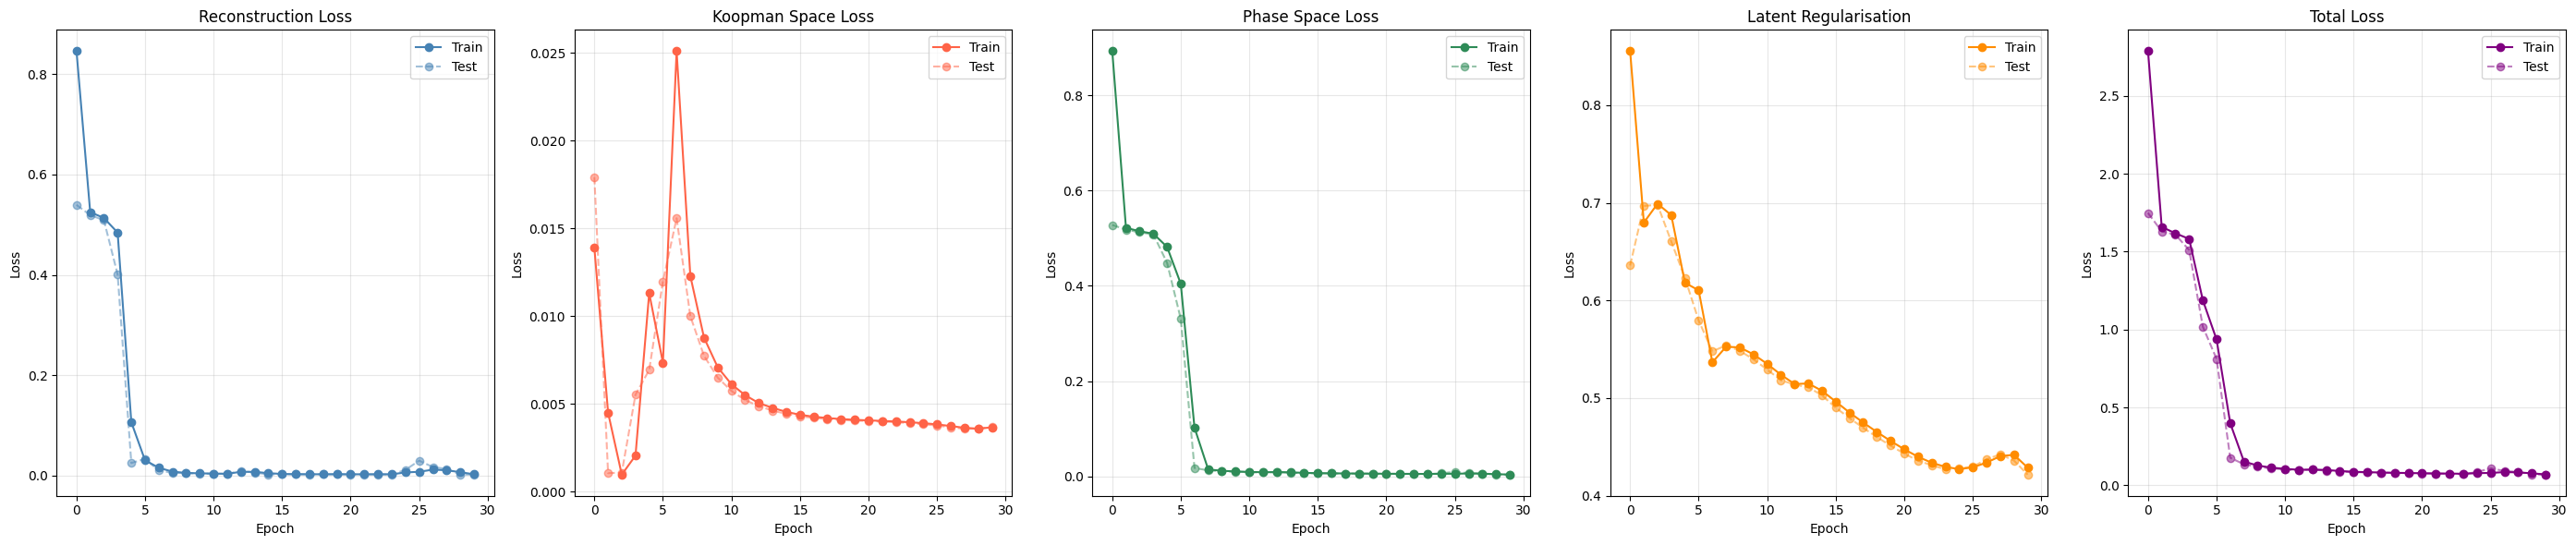

In [117]:
def plot_losses(history: dict[str, list[float]]) -> None:
    epochs = np.arange(len(history["train_total"]))
    fig, axes = plt.subplots(1, 5, figsize=(28, 6))

    plots = [
        ("recon", "Reconstruction Loss", "steelblue"),
        ("koop", "Koopman Space Loss", "tomato"),
        ("phase", "Phase Space Loss", "seagreen"),
        ("latent", "Latent Regularisation", "darkorange"),
        ("total", "Total Loss", "purple"),
    ]

    for ax, (key, title, color) in zip(axes, plots):
        ax.plot(epochs, history[f"train_{key}"], label="Train", marker="o", color=color)
        ax.plot(
            epochs,
            history[f"test_{key}"],
            label="Test",
            marker="o",
            linestyle="--",
            color=color,
            alpha=0.5,
        )
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()


plot_losses(history)


In [118]:
# TODO: Explain the loss dynamics and justify your design choices. You can plot the different part of the loss, and compare the training dynamics when using different loss functions.

0. Training fix inspired by the tips

## Loss Design Choices

The loss combines reconstruction, Koopman consistency, phase prediction, and latent regularization.

Coefficients are introduced to *balance the influence of each term, since their natural scales differ.  
In particular:
- the Koopman loss is weighted more strongly to enforce linear latent dynamics,
- the phase loss ensures correct prediction in state space,
- the reconstruction loss keeps the representation informative,
- the latent penalty has a small weight since it only stabilizes the latent distribution.

These weights prevent one objective from dominating training while still prioritizing learning a linearizable latent dynamics.

OBSERVATIONS:
- In the vanilla setup, reconstruction and phase losses dominate the objective while the Koopman loss is much smaller.
- If the Koopman loss increases before going down, it usually means the encoder is moving to help reconstruction and phase prediction faster than the linear latent dynamics can adapt.
- Freezing the encoder for the phase-space term reduces this gradient conflict and usually makes the Koopman loss curve smoother.
- Train and test curves should stay close if the stabilisation is actually helping rather than overfitting.


#### Verification

**Question 4.** : We want to ensure the Koopman operator is stable. This can be verified by checking whether its spectral radius $\rho(\mathbf{K})\le 1$. Plot the eigenvalues of the Koopman operator in order to verify the bound on its spectral radius. You can use the [`numpy.linalg.eig`](https://numpy.org/doc/stable/reference/generated/numpy.linalg.eig.html) function to retrieve the eigenvalues of a matrix.

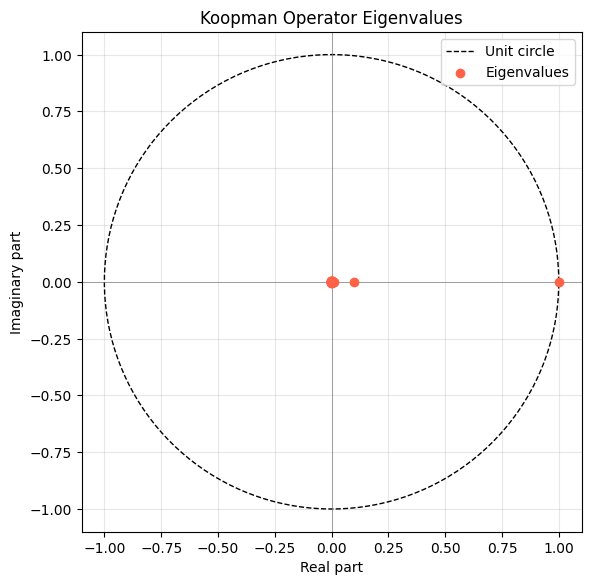

In [119]:
eigenvalues = None

# TODO: Check Koopman stability and plot the eigen values of the Koopman operator against the unit circle
K = koopman_operator.koopman_matrix()
eigenvalues = torch.linalg.eigvals(K).cpu().detach().numpy()

results["koopman_operator_eigenvalues"] = eigenvalues

# Plot eigenvalues against the unit circle
fig, ax = plt.subplots(figsize=(6, 6))

theta = np.linspace(0, 2 * np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), "k--", linewidth=1, label="Unit circle")
ax.scatter(eigenvalues.real, eigenvalues.imag, color="tomato", zorder=5, label="Eigenvalues")

ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_aspect("equal")
ax.set_title("Koopman Operator Eigenvalues")
ax.set_xlabel("Real part")
ax.set_ylabel("Imaginary part")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()


In [120]:
n_grid = 30
x1_min, x1_max = -2, 2
x2_min, x2_max = -2, 2

array_x1 = np.linspace(x1_min, x1_max, n_grid, dtype=np.float32)
array_x2 = np.linspace(x2_min, x2_max, n_grid, dtype=np.float32)
matrix_grid_x1, matrix_grid_x2 = np.meshgrid(array_x1, array_x2)

array3d_dynamics = np.zeros((n_grid, n_grid, 2), dtype=np.float32)

for i in range(n_grid):
    for j in range(n_grid):
        x1 = matrix_grid_x1[i, j]
        x2 = matrix_grid_x2[i, j]
        array3d_dynamics[i, j, :] = duffing(np.array([x1, x2]))

# Set evaluation mode
autoencoder.eval()
koopman_operator.eval()

array3d_dynamics_pred = np.zeros((n_grid, n_grid, 2), dtype=np.float32)

with torch.no_grad():
    for i in range(n_grid):
        for j in range(n_grid):
            x1 = matrix_grid_x1[i, j]
            x2 = matrix_grid_x2[i, j]
            tensor2d_x = torch.tensor([[x1, x2]], dtype=torch.float32).to(device)
            tensor2d_observable = autoencoder.encoder(tensor2d_x)
            tensor2d_koopman_observable_next = koopman_operator(tensor2d_observable)
            tensor2d_predict_x_next = autoencoder.decoder(tensor2d_koopman_observable_next)
            array_x_next = tensor2d_predict_x_next.cpu().detach().numpy().ravel()

            # Here we compute a discretised version of the derivative thanks to the Koopman operator
            # and the learned encoder/decoder

            # (x_{k+1} - x_k) / \delta_t = f(x_k) is approximated by (f is duffing here)
            # (Decod(K(Encod(x_k))) - x_k) / \delta_t

            delta_time = t_max / n_iter
            array3d_dynamics_pred[i, j, :] = (array_x_next - [x1, x2]) / delta_time


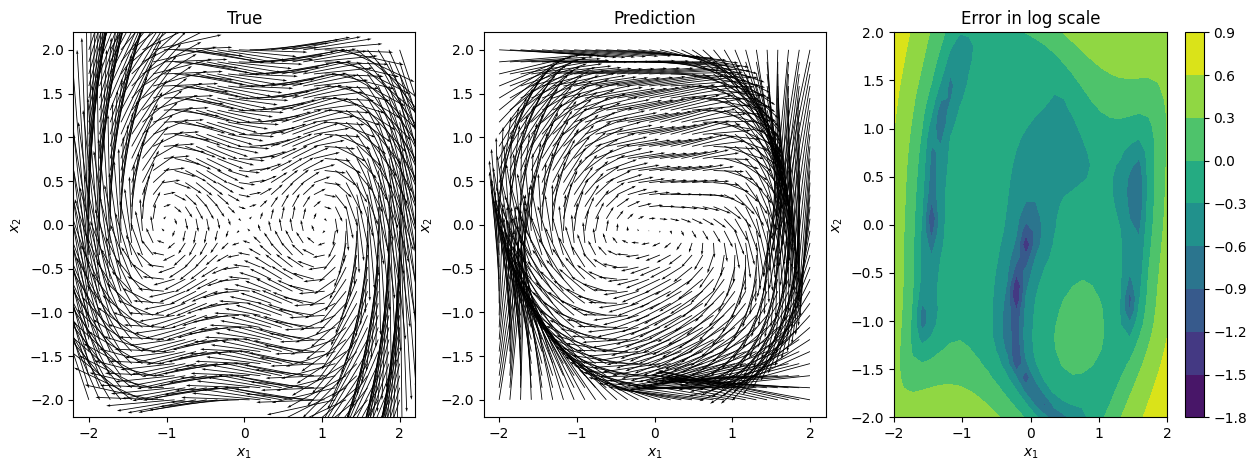

In [121]:
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(131)
ax.quiver(matrix_grid_x1, matrix_grid_x2, array3d_dynamics[:, :, 0], array3d_dynamics[:, :, 1], scale=10)
ax.set_title("True")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

ax = fig.add_subplot(132)
ax.quiver(
    matrix_grid_x1,
    matrix_grid_x2,
    array3d_dynamics_pred[:, :, 0],
    array3d_dynamics_pred[:, :, 1],
    scale=10,
)

ax.set_title("Prediction")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

# Compute the error
matrix_error = np.linalg.norm(array3d_dynamics - array3d_dynamics_pred, axis=2)
matrix_error_log = np.log10(matrix_error + 1e-10)

ax = fig.add_subplot(133)
cp = ax.contourf(matrix_grid_x1, matrix_grid_x2, matrix_error_log)

results["koopman_error_matrix"] = matrix_error

fig.colorbar(cp)
ax.set_title("Error in log scale")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.show()

### Continuous in time case

Considering $x_k$ as the observation of a state at time $t = k \delta$, and $x_{k+1}$ the state at time $t+ \delta$, for $\delta \rightarrow 0$  it is also possible to define the continuous-time infinitesimal generator of the Koopman operator family as

$$
\mathcal{L} g (x_k)  = \lim_{\delta \rightarrow 0} \frac{\mathcal{K}g(x_k)- g(x_{k})}{\delta} = \frac{g \circ F (x_k) -x_k}{\delta}
$$

The pevious expression defines the Lie derivative, and for this reason $\mathcal{L}$ is known as the Lie operator. $\mathcal{L}$ describes the continuous dynamics of the observables in the Koopman space:

$$
\dot{g} (x) = \mathcal{L} g(x).
$$

The latter can be further expressed as:

$$
\dot{g} (x(t)) = \frac{dg(x)}{dt} = \nabla_x g \frac{dx}{dt} = \nabla_x g \cdot f(x) =\mathcal{L} g(x).
$$

Given $g_{\theta}$, $\varphi_{\rho}$ and $\mathbf{L}_{\phi}$ three parameterized functions, the following conditions hold:

1.   Reconstruction error
     $$
     \Vert \varphi_\rho (g_\theta(x)) - x  \Vert = 0
     $$
2.   Prediction error in Koopman space
     $$
     \Vert \mathbf{L_{\phi}} g_{\theta} ( x ) - \nabla g_{\theta} \cdot f(x)  \Vert = 0
     $$
3.   Prediction error in the phase space
     $$
     \Vert \varphi_{\rho} \left( \mathbf{L_{\phi}} g_{\theta} ( x )\right) - f(x) \Vert = 0
     $$

**Important Remark: As long as the system $f$ is known, the three errors can be computed without data belonging to trajectories.**

In [122]:
# Create a dataset for continuous Koopman
# with the same amount of points of the Discontinuous Koopman case
# But here no need to have continuous trajectories
matrix_x0 = (np.random.rand(n_initial_conditions * (n_iter - 1), 2) - 0.5) * 4
matrix_system_derivative_data = np.zeros(matrix_x0.shape)
for i in tqdm(range(matrix_x0.shape[0])):
    matrix_system_derivative_data[i, :] = duffing(matrix_x0[i, :])

100%|██████████| 299940/299940 [00:00<00:00, 450702.97it/s]


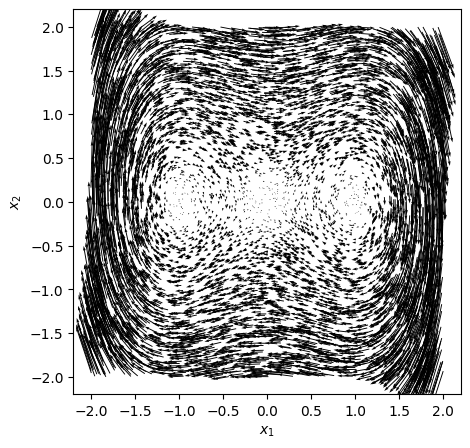

In [123]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111)
ax.quiver(
    matrix_x0[::50, 0],
    matrix_x0[::50, 1],
    matrix_system_derivative_data[::50, 0] * 0.2,
    matrix_system_derivative_data[::50, 1] * 0.2,
    scale=10,
)
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
plt.show()

In [124]:
# create the models
feature_dim = 2  # dimension of the Duffing oscillator
hidden_layer = 5  # number of hidden layers in g (ENCODER) and \varphi (DECODER)
output_dim = 30  # dimension in Koopman space
batch_size = 2000  # data per batch

In [125]:
(matrix_x_data_train, matrix_x_data_test, matrix_x_next_data_train, matrix_x_next_data_test) = (
    train_test_split(matrix_x0, matrix_system_derivative_data, test_size=0.2)
)

# Cast type to float32
matrix_x_data_train = matrix_x_data_train.astype(np.float32)
matrix_x_data_test = matrix_x_data_test.astype(np.float32)
matrix_x_next_data_train = matrix_x_next_data_train.astype(np.float32)
matrix_x_next_data_test = matrix_x_next_data_test.astype(np.float32)

print(
    matrix_x_data_train.shape,
    matrix_x_data_test.shape,
    matrix_x_next_data_train.shape,
    matrix_x_next_data_test.shape,
)

torch_dataset_train = TensorDataset(
    torch.from_numpy(matrix_x_data_train), torch.from_numpy(matrix_x_next_data_train)
)
torch_dataset_test = TensorDataset(
    torch.from_numpy(matrix_x_data_test), torch.from_numpy(matrix_x_next_data_test)
)

train_dataloader = DataLoader(torch_dataset_train, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(torch_dataset_test, batch_size=batch_size, shuffle=True)

(239952, 2) (59988, 2) (239952, 2) (59988, 2)


The Lie operator must be defined such that it will be always stable by construction.
To do that, we consider a matrix of parameters $\Psi \in \mathbb{R}^{m \times m}$ and a vector of parameters $\Gamma \in \mathbb{R}^m$. The resulting Lie operator will be of the form:

$$
\mathbf{L} = (\Psi - \Psi^T) - \text{diag}(\vert \Gamma \vert)
$$

with eigenvalues whose real part $\Re(\lambda) \leq 0$ .
See https://math.stackexchange.com/questions/952233/eigenvalues-of-the-sum-of-a-diagonal-matrix-and-a-skew-symmetric-matrix for the mathematical proof (identify the matrix). Moreover if $\lambda \in \mathbb{C}$ is an eigenvalue of $\mathbf{L}$, it turns out that its real part $\Re(\lambda) \propto \Vert \Gamma \Vert$, i.e. it only depends on $\Gamma$.

Remark: $- \text{diag}(\vert \Gamma \vert)$ is always a diagonal matrix with non-positive elements.


**Question 5.** : As you did for the discrete case, you now have to implement the `LieModule` module. It should have the form indicated above to guarantee $\Re(\lambda) \leq 0$. Check that the initialization fulfills this property.

In [126]:
class LieModule(nn.Module):
    def __init__(self, lie_operator_dim: int):
        super().__init__()
        self.lie_operator_dim = lie_operator_dim
        # TODO: Complete function
        self.raw_psi = nn.Parameter(0.02 * torch.randn(lie_operator_dim, lie_operator_dim))

        # Free vector Γ
        self.raw_gamma = nn.Parameter(0.02 * torch.randn(lie_operator_dim))

    def lie_matrix(self) -> torch.Tensor:
        skew_symmetric_part = self.raw_psi - self.raw_psi.T
        diagonal_damping = torch.diag(torch.abs(self.raw_gamma))

        return skew_symmetric_part - diagonal_damping

    def forward(self, tensor2d_x: torch.Tensor):
        if tensor2d_x.shape[1] != self.lie_operator_dim:
            sys.exit(f"Wrong Input Features. Please use tensor with {self.lie_operator_dim} Input Features")
        # TODO: Implement forward
        return tensor2d_x @ self.lie_matrix().T

In [127]:
autoencoder = Autoencoder(feature_dim, hidden_layer, output_dim).to(device)
lie_operator = LieModule(output_dim).to(device)
print(autoencoder)
results["lie_operator_weight"] = lie_operator.lie_matrix().cpu().detach().numpy()
results["lie_operator_forward"] = lie_operator(torch.ones(1, output_dim).to(device)).cpu().detach().numpy()

Autoencoder(
  (encoder): Encoder(
    (list_FC): ModuleList(
      (0): Linear(in_features=2, out_features=7, bias=True)
      (1): Linear(in_features=7, out_features=13, bias=True)
      (2): Linear(in_features=13, out_features=18, bias=True)
      (3): Linear(in_features=18, out_features=24, bias=True)
      (4): Linear(in_features=24, out_features=30, bias=True)
    )
  )
  (decoder): Decoder(
    (list_FC): ModuleList(
      (0): Linear(in_features=30, out_features=24, bias=True)
      (1): Linear(in_features=24, out_features=18, bias=True)
      (2): Linear(in_features=18, out_features=13, bias=True)
      (3): Linear(in_features=13, out_features=7, bias=True)
      (4): Linear(in_features=7, out_features=2, bias=True)
    )
  )
)


Maximum real part: -0.018980414
All real parts <= 0 ? True


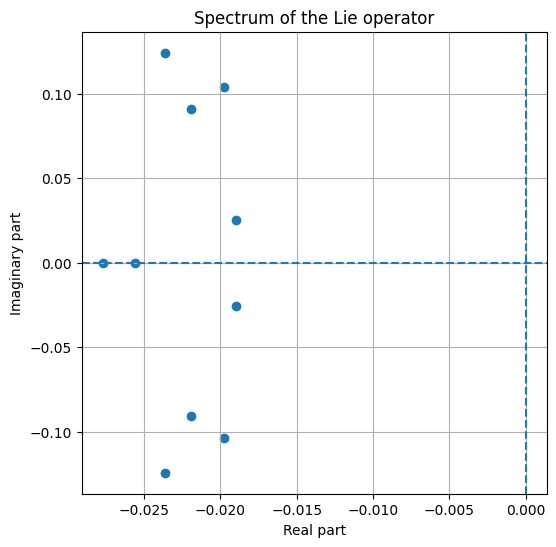

In [128]:
# TODO : Check the spectrum of the Lie operator by plotting the eigen values of the Lie operator
# Check the spectrum of the Lie operator by plotting its eigenvalues
lie_module = LieModule(dim_observable).to(device)

lie_matrix = lie_module.lie_matrix().detach().cpu()
eigvals = torch.linalg.eigvals(lie_matrix)

eigvals_real = eigvals.real.numpy()
eigvals_imag = eigvals.imag.numpy()

print("Maximum real part:", eigvals_real.max())
print("All real parts <= 0 ?", np.all(eigvals_real <= 1e-8))

plt.figure(figsize=(6, 6))
plt.scatter(eigvals_real, eigvals_imag)
plt.axvline(0.0, linestyle="--")
plt.axhline(0.0, linestyle="--")
plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.title("Spectrum of the Lie operator")
plt.grid(True)
plt.show()

Some tricks are needed to train. If the autoencoder and the Lie model are learned at the same speed, the training turns out to be highly unstable since the three loss functions have moving targets. For this reason, the Lie learning rate has been chosen smaller than the autoencoder one.

In [129]:
learning_rate_autoencoder = 0.0001
learning_rate_lie = 0.00001

optimiser_autoencoder = torch.optim.Adam(
    autoencoder.parameters(), lr=learning_rate_autoencoder, weight_decay=1e-3
)
optimiser_lie = torch.optim.Adam(lie_operator.parameters(), lr=learning_rate_lie, weight_decay=1e-3)

A further loss is considered to stabilize the learning stage. The state $x$ belongs to a compact set, since it is the solution of a dissipative dynamical system. This is not true for $g(x)$ (we need to choose appropriate activation functions to have appropriate Liptchitz guarantees). To avoid discrepancies in magnitudes of $g_i(x)$, a regularization loss is added:

$$
\mu = \frac{1}{m} \sum_m g_i(x) = 0  \quad \text{and} \quad  \sigma = \left( \frac{1}{m}\sum_m(g_i(x)-\mu)^2 \right)^{1/2} = 1
$$

inspired by VAE.

For the training to be smooth, the encoder parameters are not affected by the **prediction loss in phase space**. This is based on an empirical observation and is motivated by the fact that the encoder appears in the three losses and plays a competitive role against the decoder and the Lie model. This should not affect the results since the encoder remains coupled with the decoder in the **reconstruction loss** and with the Lie operator in the **prediction loss in Koopman space**.

**Question 6.** : Implement the loss function similarly to what you did for the **Question 2.** Note that here you should use the dynamics $f$ and its values for a set of points belonging to the domain $\left[ -2, 2 \right]^2$ while no data from proper **trajectories** are needed.

In [130]:
# Implement the loss function here
# See the training process below to identify the different components of the loss
def loss_lie(
    tensor2d_x: torch.Tensor,
    tensor2d_x_next: torch.Tensor,
    tensor2d_decoded_x: torch.Tensor,
    tensor2d_observable: torch.Tensor,
    tensor2d_lie_observable: torch.Tensor,
    tensor2d_predict_x: torch.Tensor,
    tensor2d_jvp: torch.Tensor,
):
    criterion = nn.MSELoss()

    # 1. Reconstruction loss
    loss_reconstruction = criterion(tensor2d_decoded_x, tensor2d_x)

    # 2. Koopman / Lie-space prediction loss
    loss_koopman_space = criterion(tensor2d_lie_observable, tensor2d_jvp)

    # 3. Phase-space prediction loss
    # Here tensor2d_x_next should correspond to f(x)
    loss_phase_space = criterion(tensor2d_predict_x, tensor2d_x_next)

    # 4. Latent-space regularization
    latent_mean_penalty = tensor2d_observable.mean(dim=0).pow(2).mean()
    latent_std_penalty = (tensor2d_observable.std(dim=0) + 1e-6 - 1.0).pow(2).mean()
    loss_latent = latent_mean_penalty + latent_std_penalty

    # Weights
    lambda_recon = 1.0
    lambda_koop = 5.0
    lambda_phase = 2.0
    lambda_latent = 0.1

    total_loss = (
        lambda_recon * loss_reconstruction
        + lambda_koop * loss_koopman_space
        + lambda_phase * loss_phase_space
        + lambda_latent * loss_latent
    )

    return total_loss, loss_reconstruction, loss_koopman_space, loss_phase_space, loss_latent


**Since trajectories are not needed**, random states can be sampled from the system manifold $x_1 \in [-2, 2]$, $x_2 \in [-2, 2]$.

In [131]:
def train_lie(n_epoch: int = 30):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(0)
    np.random.seed(0)

    feature_dim = 2
    hidden_layer = 5
    output_dim = 30

    autoencoder = Autoencoder(feature_dim, hidden_layer, output_dim).to(device)
    lie_operator = LieModule(output_dim).to(device)

    optimiser_autoencoder = torch.optim.Adam(autoencoder.parameters(), lr=3e-4, weight_decay=1e-6)
    optimiser_lie = torch.optim.Adam(lie_operator.parameters(), lr=1e-4)

    history = {
        "train_total": [],
        "test_total": [],
        "train_recon": [],
        "test_recon": [],
        "train_koop": [],
        "test_koop": [],
        "train_phase": [],
        "test_phase": [],
        "train_latent": [],
        "test_latent": [],
    }

    n_batch = len(train_dataloader)
    n_test = len(test_dataloader)

    for epoch in range(n_epoch):
        autoencoder.train()
        lie_operator.train()

        total_train_loss = 0.0
        total_train_recon = 0.0
        total_train_koop = 0.0
        total_train_phase = 0.0
        total_train_latent = 0.0

        for tensor2d_batch_x, tensor2d_batch_x_next in train_dataloader:
            tensor2d_batch_x = tensor2d_batch_x.to(device)
            tensor2d_batch_x_next = tensor2d_batch_x_next.to(device)

            optimiser_autoencoder.zero_grad()
            optimiser_lie.zero_grad()

            # observable = g(x)
            # jvp = J_g(x) f(x)
            tensor2d_observable, tensor2d_jvp = autograd.functional.jvp(
                autoencoder.encoder,
                tensor2d_batch_x,
                tensor2d_batch_x_next,
                create_graph=True,
            )

            tensor2d_decoded_x = autoencoder.decoder(tensor2d_observable)
            tensor2d_lie_observable = lie_operator(tensor2d_observable)

            # Phase-space loss should not update the encoder
            tensor2d_predict_x = autoencoder.decoder(lie_operator(tensor2d_observable.detach()))

            tensor_loss, l_recon, l_koop, l_phase, l_latent = loss_lie(
                tensor2d_x=tensor2d_batch_x,
                tensor2d_x_next=tensor2d_batch_x_next,
                tensor2d_observable=tensor2d_observable,
                tensor2d_decoded_x=tensor2d_decoded_x,
                tensor2d_lie_observable=tensor2d_lie_observable,
                tensor2d_predict_x=tensor2d_predict_x,
                tensor2d_jvp=tensor2d_jvp,
            )

            main_loss = 1.0 * l_recon + 5.0 * l_koop + 0.1 * l_latent
            main_loss.backward(retain_graph=True)

            for p in autoencoder.encoder.parameters():
                p.requires_grad = False

            phase_only_loss = 2.0 * l_phase
            phase_only_loss.backward()

            for p in autoencoder.encoder.parameters():
                p.requires_grad = True

            nn.utils.clip_grad_norm_(autoencoder.parameters(), max_norm=1.0)
            nn.utils.clip_grad_norm_(lie_operator.parameters(), max_norm=1.0)

            optimiser_autoencoder.step()
            optimiser_lie.step()

            total_train_loss += tensor_loss.item()
            total_train_recon += l_recon.item()
            total_train_koop += l_koop.item()
            total_train_phase += l_phase.item()
            total_train_latent += l_latent.item()

        autoencoder.eval()
        lie_operator.eval()

        total_test_loss = 0.0
        total_test_recon = 0.0
        total_test_koop = 0.0
        total_test_phase = 0.0
        total_test_latent = 0.0

        for tensor2d_batch_x, tensor2d_batch_x_next in test_dataloader:
            tensor2d_batch_x = tensor2d_batch_x.to(device)
            tensor2d_batch_x_next = tensor2d_batch_x_next.to(device)

            with torch.enable_grad():
                tensor2d_observable, tensor2d_jvp = autograd.functional.jvp(
                    autoencoder.encoder,
                    tensor2d_batch_x,
                    tensor2d_batch_x_next,
                    create_graph=False,
                )

            with torch.no_grad():
                tensor2d_decoded_x = autoencoder.decoder(tensor2d_observable)
                tensor2d_lie_observable = lie_operator(tensor2d_observable)
                tensor2d_predict_x = autoencoder.decoder(tensor2d_lie_observable)

                tensor_loss, l_recon, l_koop, l_phase, l_latent = loss_lie(
                    tensor2d_x=tensor2d_batch_x,
                    tensor2d_x_next=tensor2d_batch_x_next,
                    tensor2d_observable=tensor2d_observable,
                    tensor2d_decoded_x=tensor2d_decoded_x,
                    tensor2d_lie_observable=tensor2d_lie_observable,
                    tensor2d_predict_x=tensor2d_predict_x,
                    tensor2d_jvp=tensor2d_jvp,
                )

                total_test_loss += tensor_loss.item()
                total_test_recon += l_recon.item()
                total_test_koop += l_koop.item()
                total_test_phase += l_phase.item()
                total_test_latent += l_latent.item()

        print(
            f"Epoch {epoch:02d} | "
            f"Train: total={total_train_loss / n_batch:.4f} recon={total_train_recon / n_batch:.4f} "
            f"koop={total_train_koop / n_batch:.4f} phase={total_train_phase / n_batch:.4f} "
            f"latent={total_train_latent / n_batch:.4f} | "
            f"Test: total={total_test_loss / n_test:.4f} recon={total_test_recon / n_test:.4f} "
            f"koop={total_test_koop / n_test:.4f} phase={total_test_phase / n_test:.4f} "
            f"latent={total_test_latent / n_test:.4f}"
        )

        history["train_total"].append(total_train_loss / n_batch)
        history["test_total"].append(total_test_loss / n_test)
        history["train_recon"].append(total_train_recon / n_batch)
        history["test_recon"].append(total_test_recon / n_test)
        history["train_koop"].append(total_train_koop / n_batch)
        history["test_koop"].append(total_test_koop / n_test)
        history["train_phase"].append(total_train_phase / n_batch)
        history["test_phase"].append(total_test_phase / n_test)
        history["train_latent"].append(total_train_latent / n_batch)
        history["test_latent"].append(total_test_latent / n_test)

    eigvals = torch.linalg.eigvals(lie_operator.lie_matrix()).detach().cpu().numpy()
    print("Max real part:", eigvals.real.max())

    return autoencoder, lie_operator, history

Epoch 00 | Train: total=6.5823 recon=1.1339 koop=0.0104 phase=2.6547 latent=0.8687 | Test: total=5.6287 recon=0.7305 koop=0.0165 phase=2.3698 latent=0.7592
Epoch 01 | Train: total=4.2646 recon=0.5153 koop=0.0118 phase=1.8076 latent=0.7504 | Test: total=3.0764 recon=0.2017 koop=0.0174 phase=1.3603 latent=0.6705
Epoch 02 | Train: total=2.3916 recon=0.0711 koop=0.0118 phase=1.0957 latent=0.7020 | Test: total=2.1374 recon=0.0378 koop=0.0057 phase=0.9969 latent=0.7754
Epoch 03 | Train: total=2.0542 recon=0.0332 koop=0.0042 phase=0.9596 latent=0.8071 | Test: total=1.9779 recon=0.0294 koop=0.0033 phase=0.9245 latent=0.8315
Epoch 04 | Train: total=1.9464 recon=0.0268 koop=0.0029 phase=0.9103 latent=0.8443 | Test: total=1.9131 recon=0.0245 koop=0.0026 phase=0.8951 latent=0.8522
Epoch 05 | Train: total=1.8993 recon=0.0219 koop=0.0026 phase=0.8894 latent=0.8578 | Test: total=1.8879 recon=0.0194 koop=0.0025 phase=0.8849 latent=0.8620
Epoch 06 | Train: total=1.8573 recon=0.0162 koop=0.0024 phase=0.

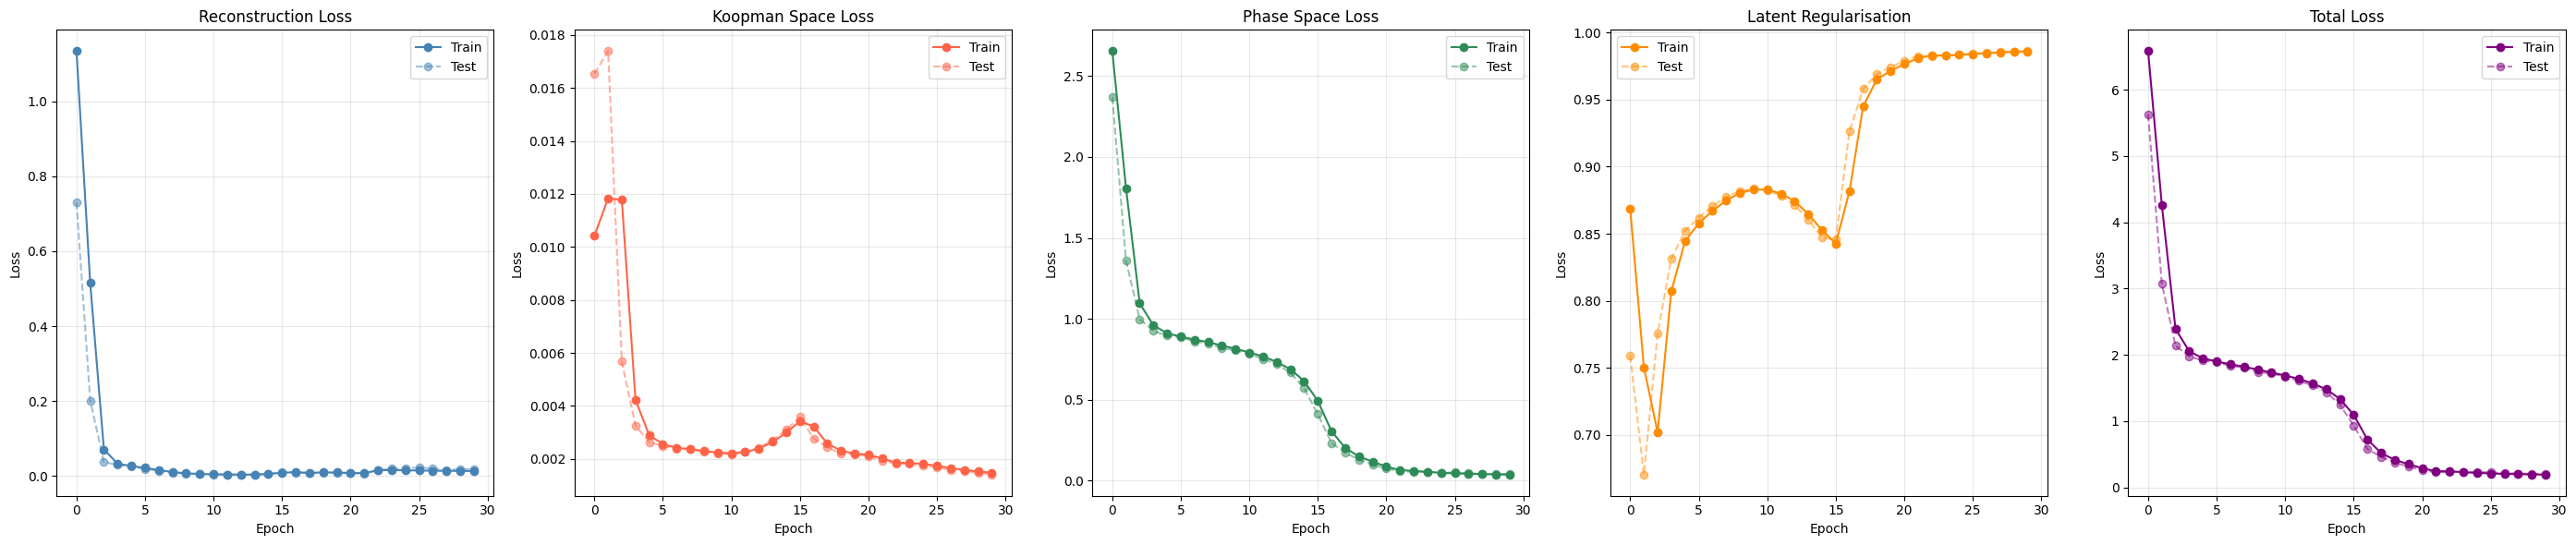

In [132]:
autoencoder, lie_operator, history = train_lie(n_epoch=30)
plot_losses(history)

In [133]:
results["losses_lie"] = {
    "train": np.array(history["train_total"]),
    "test": np.array(history["test_total"]),
    "weight_lie": lie_operator.lie_matrix().cpu().detach().numpy(),
    "weight_encoder": [layer.weight.detach().cpu().numpy() for layer in autoencoder.encoder.list_FC],
    "weight_decoder": [layer.weight.detach().cpu().numpy() for layer in autoencoder.decoder.list_FC],
}


### Verification

**Question 7.** : As in the **Question 3.** we want to ensure the Lie operator is stable. This can be verified by checking that the real part of the eigenvalues is negative. Plot the relevant eigenvalues of the Lie operator. 

In [134]:
lie_operator_eigenvalues = None
# TODO: Check the eigenvalues real part
lie_matrix = lie_operator.lie_matrix().detach().cpu()
lie_operator_eigenvalues = torch.linalg.eigvals(lie_matrix).numpy()
results["lie_operator_eigenvalues"] = lie_operator_eigenvalues
print("Max real part:", eigvals.real.max().item())

Max real part: -0.018980413675308228


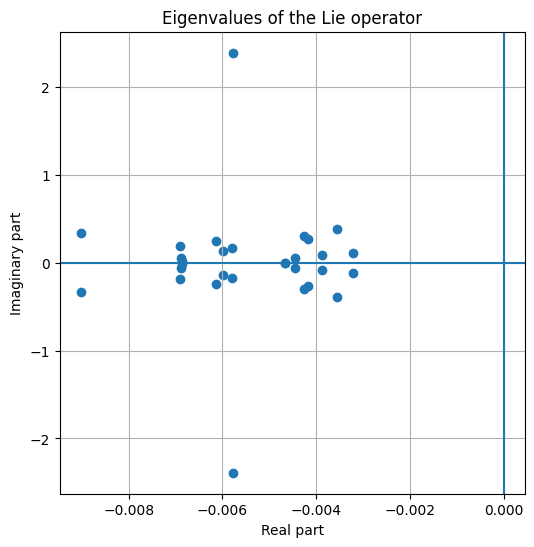

In [135]:
# TODO: Plot the eigenvalues
eigvals = results["lie_operator_eigenvalues"]

real_part = np.real(eigvals)
imag_part = np.imag(eigvals)

plt.figure(figsize=(6, 6))
plt.scatter(real_part, imag_part)

plt.axvline(0.0)  # imaginary axis
plt.axhline(0.0)

plt.xlabel("Real part")
plt.ylabel("Imaginary part")
plt.title("Eigenvalues of the Lie operator")
plt.grid(True)

plt.show()

In [136]:
n_grid = 30
array_x1 = np.linspace(x1_min, x1_max, n_grid, dtype=np.float32)
array_x2 = np.linspace(x2_min, x2_max, n_grid, dtype=np.float32)
matrix_grid_x1, matrix_grid_x2 = np.meshgrid(array_x1, array_x2)

array3d_dynamics = np.zeros((n_grid, n_grid, 2))

for i in range(n_grid):
    for j in range(n_grid):
        array3d_dynamics[i, j, :] = duffing(np.array([matrix_grid_x1[i, j], matrix_grid_x2[i, j]]))

autoencoder.eval()
lie_operator.eval()
array3d_dynamics_pred = np.zeros((n_grid, n_grid, 2))
for i in range(n_grid):
    for j in range(n_grid):
        x1 = matrix_grid_x1[i, j]
        x2 = matrix_grid_x2[i, j]
        tensor2d_x = torch.tensor([[x1, x2]], dtype=torch.float32).to(device)
        tensor2d_observable = autoencoder.encoder(tensor2d_x)
        tensor2d_lie_observable_next = lie_operator(tensor2d_observable)
        tensor2d_predict_x_next = autoencoder.decoder(tensor2d_lie_observable_next)
        array_x_next = tensor2d_predict_x_next.cpu().detach().numpy().ravel()

        array3d_dynamics_pred[i, j, :] = array_x_next


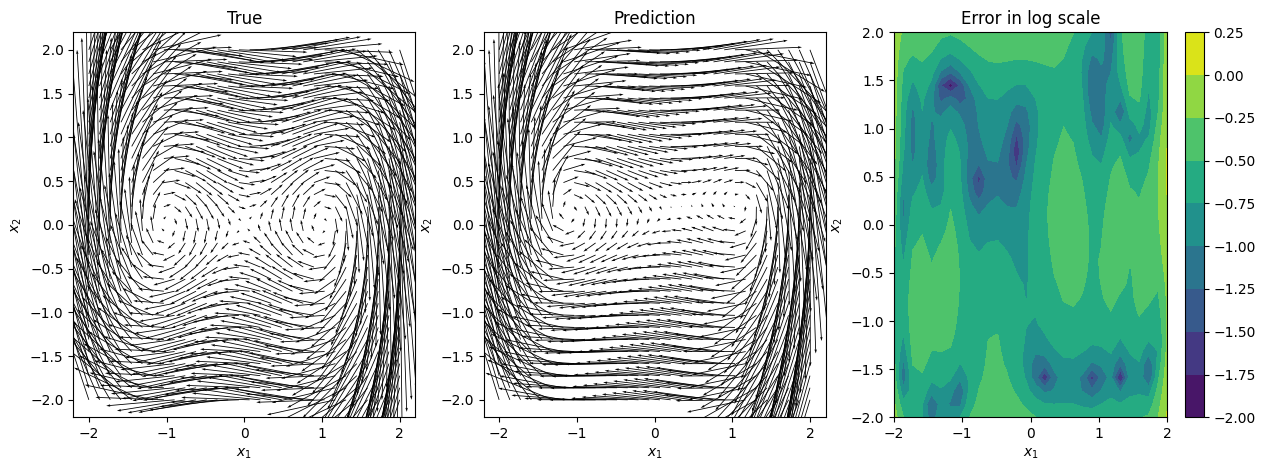

In [137]:
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(131)
ax.quiver(matrix_grid_x1, matrix_grid_x2, array3d_dynamics[:, :, 0], array3d_dynamics[:, :, 1], scale=10)
ax.set_title("True")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

ax = fig.add_subplot(132)
ax.quiver(
    matrix_grid_x1, matrix_grid_x2, array3d_dynamics_pred[:, :, 0], array3d_dynamics_pred[:, :, 1], scale=10
)
ax.set_title("Prediction")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

ax = fig.add_subplot(133)
matrix_error = np.linalg.norm(array3d_dynamics - array3d_dynamics_pred, axis=2)
matrix_error_log = np.log10(matrix_error + 1e-10)
results["lie_error_matrix"] = matrix_error

cp = ax.contourf(matrix_grid_x1, matrix_grid_x2, matrix_error_log)
fig.colorbar(cp)
ax.set_title("Error in log scale")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

plt.show()

**Question 8.** : Compare and comment below the two approaches (discrete vs continuous operator).

In our experiments, the continuous/global formulation performed better, learning more coherent global structures in the phase space. The discrete model fit one-step transitions well but produced poorer global dynamics when visualizing the vector field. In addition the discrete approach was very difficult to stabilise as instabilites would often happen during training.

*-- PLEASE SUBMIT YOUR COMPLETED NOTEBOOK WITH CELL OUTPUTS --* 

*--Do not forget to submit the `.npy` file generated from the `results` dictionary--*

In [144]:
name = "KAPOTOS_DEGENEVE"  # TODO
file_path = f"Week5/results_{name}.npy"
np.save(file_path, results)

loaded_results = np.load(file_path, allow_pickle=True).item()
print(loaded_results.keys())
assert len(loaded_results.keys()) == 11

dict_keys(['id', 'koopman_operator_weight', 'koopman_operator_forward', 'losses_koopman', 'koopman_operator_eigenvalues', 'koopman_error_matrix', 'lie_operator_weight', 'lie_operator_forward', 'losses_lie', 'lie_operator_eigenvalues', 'lie_error_matrix'])


In [145]:
for key in loaded_results.keys():
    if type(loaded_results[key]) is dict:
        for subkey in loaded_results[key].keys():
            print(
                f"{key} - {subkey} : {type(loaded_results[key][subkey])} with shape {loaded_results[key][subkey].shape if isinstance(loaded_results[key][subkey], np.ndarray) else 'N/A'}"
            )
    else:
        print(
            f"{key} : {type(loaded_results[key])} with shape {loaded_results[key].shape if isinstance(loaded_results[key], np.ndarray) else 'N/A'}"
        )

id : <class 'int'> with shape N/A
koopman_operator_weight : <class 'numpy.ndarray'> with shape (10, 10)
koopman_operator_forward : <class 'numpy.ndarray'> with shape (1, 10)
losses_koopman - train : <class 'numpy.ndarray'> with shape (30,)
losses_koopman - test : <class 'numpy.ndarray'> with shape (30,)
losses_koopman - weight_koopman : <class 'numpy.ndarray'> with shape (30, 30)
losses_koopman - weight_encoder : <class 'list'> with shape N/A
losses_koopman - weight_decoder : <class 'list'> with shape N/A
koopman_operator_eigenvalues : <class 'numpy.ndarray'> with shape (30,)
koopman_error_matrix : <class 'numpy.ndarray'> with shape (30, 30)
lie_operator_weight : <class 'numpy.ndarray'> with shape (30, 30)
lie_operator_forward : <class 'numpy.ndarray'> with shape (1, 30)
losses_lie - train : <class 'numpy.ndarray'> with shape (30,)
losses_lie - test : <class 'numpy.ndarray'> with shape (30,)
losses_lie - weight_lie : <class 'numpy.ndarray'> with shape (30, 30)
losses_lie - weight_encod